# Accessing root files

The goal of this notebook is to put into practice the skills learned in the Uproot Tutorial

### Installing packages

In [3]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import vector
import matplotlib

### Open file and print the file trees

In [4]:
file = uproot.open('sample_root_files/output_570.root') # Opening file

In [5]:
file.keys()                                             # Printing all trees

['Events;1', 'LuminosityBlocks;1', 'Runs;1', 'untagged;1']

### Open events tree and open EFTfitCoefficients branch inside events tree

In [6]:
events_tree = file['Events']                            # Assigning events tree to events_tree
# print(events_tree.keys())

In [7]:
eft_coeff = events_tree['EFTfitCoefficients'].array()   # Using EFTfitCoefficients branch and converting it into array

### Finding the total sum of the coefficients in all events

In [8]:
sum_of_coeff = []                                       # Empty list

for coefficient in np.arange(0,len(eft_coeff[0])):
  b = 0                                                 # We will store the total sum of each coefficient in the following step:
  b = np.sum(eft_coeff[:,coefficient])
  sum_of_coeff.append(b)                                # Store the value in the empty list

### _Results_

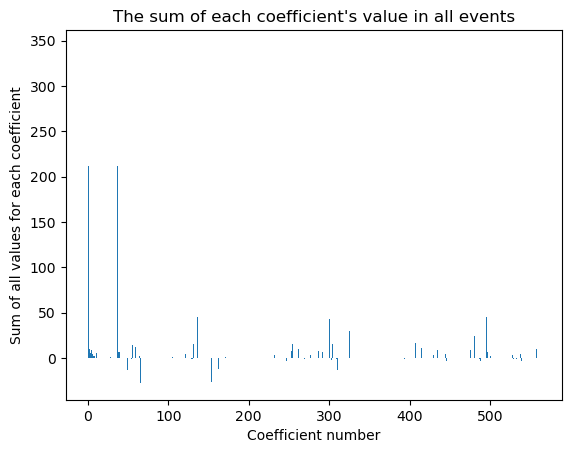

In [9]:
plt.bar(np.arange(1,562),np.array(sum_of_coeff))        # We use plt.bar and not plt.hist since we already have the x and y values!
plt.xlabel('Coefficient number')
plt.ylabel('Sum of all values for each coefficient')
plt.title(r"The sum of each coefficient's value in all events")
plt.show()

### We could also do a (not really informative) histogram of all the values of the coefficients:

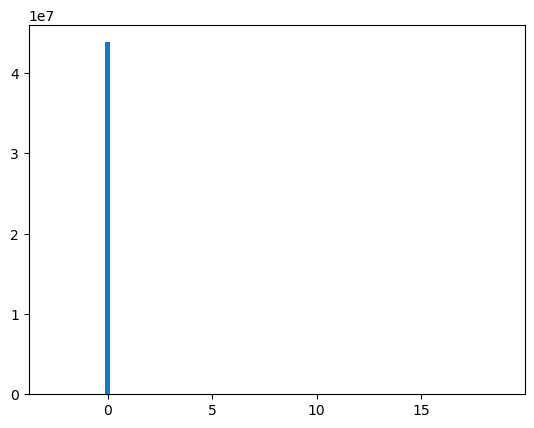

In [10]:
plt.hist(ak.flatten(eft_coeff), bins = 100)
plt.show()

## Plotting 3-D graph with the following axis:
* x axis is the event number.
* y axis is the number of the coefficient.
* the color is the value of the coefficient.

### Setting event numbers and number of coefficients

In [11]:
x_axis = np.arange(1,len(eft_coeff)+1)                  # Setting event numbers
y_axis = np.arange(1, len(eft_coeff[0])+1)              # Setting coefficient numbers

### Making a list from 1 to 561 for each event

In [35]:
%%time

b = False
event_number = 0
coefficients = []
while b == False:                                       # This while loop repeats the y_axis so we can assign 561 coefficients to 
    for i in y_axis:                                    # a single event (equivalent of assigning 561 y-values to a single x-value).
        coefficients.append(i)
    event_number += 1
    if event_number == len(x_axis):
        b = True

CPU times: user 2.96 s, sys: 467 ms, total: 3.43 s
Wall time: 3.44 s


### Eventually I found another way to do the stuff above that is more efficient:

In [39]:
%%time

coeffs = list(range(1,562)) * len(x_axis)
coeffs == coefficients

CPU times: user 1.3 s, sys: 52.6 ms, total: 1.35 s
Wall time: 1.36 s


True

### _Results_

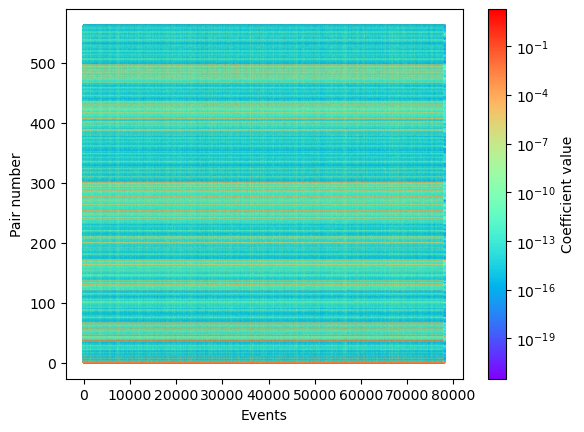

CPU times: user 5min 58s, sys: 1.94 s, total: 6min
Wall time: 6min 1s


In [13]:
%%time
# Graphing the scatter plot

plt.scatter(np.repeat(x_axis, len(y_axis)), np.array(coeffs), c = np.array(ak.flatten(eft_coeff)), cmap='rainbow', 
            s = 0.5, norm=matplotlib.colors.LogNorm())
# plt.yscale('log')
# plt.xscale('log')
plt.xlabel('Events')
plt.ylabel('Pair number')
plt.colorbar(label='Coefficient value')
plt.show()